
## Proyecto Final  — Predicción del valor de compra en Tiendas Duty Free Aeropuerto de Tocumen : “Un enfoque práctico de regresión” 


**S100 · Introducción a la Ciencia de Datos** · Maestría en Analítica de Datos, UTP
**Prof. Gabriel Soto, M.Sc.** · II Semestre 2026

**Modalidad:** Grupal · **Datos:** `VentasWisaConsolidado.csv` (1,102,317 facturas)

**Grupo No. 5:** Integrantes :** Jorge Gonzalez, Nelson Pimentel, Gerineldo Sousa y Jorge Novarro. 


---

## Background 

La industria del travel retail y las tiendas libres de impuestos (duty free) ubicadas en aeropuertos representan un segmento comercial de gran relevancia económica a nivel mundial, impulsado por los flujos internacionales de pasajeros y el gasto asociado al turismo. 
La Riviera Duty Free opera varios puntos de venta dentro del Aeropuerto Internacional de Tocumen, uno de los principales centros de conexión aérea de Latinoamérica, atendiendo a un flujo constante de viajeros de múltiples nacionalidades. A diferencia del comercio minorista tradicional, este tipo de tienda depende fuertemente de factores estacionales asociados al calendario de vacaciones y a los flujos de turismo, y maneja una gran variedad de categorías de producto (fragancias, cosméticos, licores, accesorios, cigarrillos) orientadas a distintos perfiles de cliente. Este proyecto utiliza los datos de seis de sus tiendas dentro del mismo aeropuerto, WISA-01, WISA-02, WISA-03, WISA-04, WISA-05 y WISA-MAC, lo que además permite explorar si el punto de venta específico influye en el comportamiento de compra.

---


---

## Análisis Exploratorio — Ventas Tiendas Duty Free (La Riviera)

Este notebook desarrolla el proyecto final del curso *Introducción a la Ciencia de Datos* (Maestría en Analítica de Datos, UTP), siguiendo la formulación entregada previamente:

1. Se combinan los datos de venta de seis tiendas de La Riviera Duty Free en el Aeropuerto Internacional de Tocumen: **WISA-01** a **WISA-06(WISA-MAC)** (enero–noviembre de 2011).
2. **Modelo de regresión:** predecir `TOTAL_FACTURA`, el valor total de una transacción, a partir de tienda, mes/trimestre, tamaño de la canasta, clase de producto y perfil de cliente.

> **Antes de ejecutar:** coloca `VentasWisaConsolidado.csv`  en la misma carpeta que este notebook (son los archivos originales que ya tienes).


---


### Diccionario de Variables 
A continuación, se describen las variables principales utilizadas para el modelo y el análisis:

| Variable | Descripción |
| :--- | :--- |
| **TIENDA** | Punto de venta donde ocurre la transacción (WISA-01 a WISA-MAC), ambos dentro del Aeropuerto Internacional de Tocumen. |
| **MES / TRIMESTRE** | Periodo del año en que ocurre la transacción, para capturar el efecto estacional identificado en el análisis exploratorio. |
| **NUM_LINEAS** | Número de artículos distintos incluidos en la factura (derivada agrupando el archivo por TIENDA + FACTURA). |
| **CANTIDAD_TOTAL** | Suma de unidades compradas en toda la factura (derivada). |
| **DES_CLASE_PRINCIPAL** | Clase de producto (fragancias, cosméticos, licores, accesorios, cigarrillos) con mayor monto dentro de la factura (derivada). |
| **GENERO_PRINCIPAL** | Género objetivo (femenino/masculino/unisex) predominante entre los artículos de la factura (derivada). |
| **PAIS_CLIENTE (agrupado)** | País declarado por el cliente; los países con menor frecuencia se agruparán en la categoría "OTROS". |

In [43]:
from IPython.display import display, Markdown, HTML
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Rutas de los archivos (deben estar en la misma carpeta que este notebook)

VENTAS_PATH = "VentasDutyFree.csv"

# Rutas de los archivos (deben estar en la misma carpeta que este notebook)

WISA1_PATH = "VentasWisa1.csv"
WISA2_PATH = "VentasWisa2.csv"
WISA3_PATH = "VentasWisa3.csv"

WISA4_PATH = "VentasWisa4.csv"
WISA5_PATH = "VentasWisa5.csv"
WISA6_PATH = "VentasWisa6.csv"


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



def formato_dinero(x, pos):
    if x >= 1e6:
        return f'${x*1e-6:.1f}M'
    elif x >= 1e3:
        return f'${x*1e-3:.0f}K'
    return f'${x:.0f}'

fmt = FuncFormatter(formato_dinero)

AZUL = "#13294B"
plt.rcParams.update({"figure.figsize": (8, 4.2), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "axes.axisbelow": True,
                     "grid.color": "#D3D8E0", "axes.titleweight": "bold", "font.size": 10})

pd.set_option("display.float_format", lambda x: "%.2f" % x)

pd.set_option("styler.render.repr", "html")


# --- Estilo de los gráficos (paleta consistente, un color por serie) ---
%matplotlib inline
CAT_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#184f95"]
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
SURFACE = "#fcfcfb"

mpl.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK_SECONDARY,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "grid.color": GRID,
    "axes.grid": True,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
print("Librerías cargadas correctamente.")



Librerías cargadas correctamente.


### 1. Carga inicial de datos
Primero cargamos la base consolidada de La Riviera. Le damos un vistazo rápido a la estructura y validamos el tamaño del archivo para asegurar que todo cuadre.

In [44]:
#df = pd.read_csv(VENTAS_PATH, dtype=str, low_memory=False)

df1 = pd.read_csv(WISA1_PATH, dtype=str, low_memory=False)
df2 = pd.read_csv(WISA2_PATH, dtype=str, low_memory=False)
df3 = pd.read_csv(WISA3_PATH, dtype=str, low_memory=False)
df4 = pd.read_csv(WISA4_PATH, dtype=str, low_memory=False)
df5 = pd.read_csv(WISA5_PATH, dtype=str, low_memory=False)
df6 = pd.read_csv(WISA6_PATH, dtype=str, low_memory=False)

df = pd.concat([df1, df2, df3, df4, df5, df6], ignore_index=True)

del df1, df2, df3, df4, df5, df6

print("="*100)
print("Ventas Duty Free - Análisis Exploratorio de Datos carga de datos")
#df = pd.read_csv("VentasDutyFree.csv", dtype=str,low_memory=False)
print("Filas y columnas:", df.shape)
print("="*100)
print("\n")

# Columnas del DataFrame
print("="*100)
print("Columnas del DataFrame")
print("="*100)
info_dataframe = df.info()
display(info_dataframe)


Ventas Duty Free - Análisis Exploratorio de Datos carga de datos
Filas y columnas: (1102317, 56)


Columnas del DataFrame
<class 'pandas.DataFrame'>
RangeIndex: 1102317 entries, 0 to 1102316
Data columns (total 56 columns):
 #   Column                  Non-Null Count    Dtype
---  ------                  --------------    -----
 0   NO_CIA                  1102317 non-null  str  
 1   NOMBRE_EMPRESA          1102317 non-null  str  
 2   UNIDAD_NEGOCIO          1102317 non-null  str  
 3   NOMBRE_UNIDAD           1102317 non-null  str  
 4   CENTRO                  1102317 non-null  str  
 5   BODEGA                  1102317 non-null  str  
 6   NOMBRETIENDA            1102317 non-null  str  
 7   FACTURA                 1102317 non-null  str  
 8   FECHA                   1102317 non-null  str  
 9   ARTICULO                1102317 non-null  str  
 10  NOMBREARTICULO          1102317 non-null  str  
 11  MARCA                   1102317 non-null  str  
 12  NOMBREMARCA             11023

None

Verificamos las primeras filas y el resumen estadístico base:

In [45]:

print("="*100)
print("Primeras 3 filas del DataFrame")
print("="*100)

display(df.head(3))

print("="*100)
print("Resumen Estadístico")
print("="*100)

print("\n--- Resumen Estadístico ---")

display(df.describe())
display(Markdown("### Registros por Tienda"))
display(pd.DataFrame(df["NOMBRETIENDA"].value_counts()).rename(columns={"count": "Registros", "NOMBRETIENDA": "Tienda"}).style.background_gradient(cmap='Blues'))

# Valores faltantes
print("="*100)
print("Valores faltantes por columna")
print("="*100)
faltan = df.isna().sum()
display(faltan[faltan > 0])


Primeras 3 filas del DataFrame


,NO_CIA,NOMBRE_EMPRESA,UNIDAD_NEGOCIO,NOMBRE_UNIDAD,CENTRO,BODEGA,NOMBRETIENDA,FACTURA,FECHA,ARTICULO,...,FECHA_CARGA,FECHA_HORA_TRANSACCION,PAIS_CLIENTE,SEMANA_ANIO,DESC_SEMANA_ANIO,SEMESTRE,DESC_SEMESTRE,DESC_TRIMESTRE,DESC_MES,TRIMESTRE
0,01,LA RIVIERA DUTY FREE,01,DUTY FREE,01,0101,WISA 01,A-500420,06/01/11,BT1-175,...,14/09/18,06/01/11,SIN PAIS CARGADO,1,Wk-01,1,Sem I,Trim I,Enero,1
1,01,LA RIVIERA DUTY FREE,01,DUTY FREE,01,0101,WISA 01,A-510376,30/01/11,BT1-175,...,14/09/18,30/01/11,SIN PAIS CARGADO,5,Wk-05,1,Sem I,Trim I,Enero,1
2,01,LA RIVIERA DUTY FREE,01,DUTY FREE,01,0101,WISA 01,A-499300,03/01/11,BT1-002,...,14/09/18,03/01/11,BRASIL,1,Wk-01,1,Sem I,Trim I,Enero,1


Resumen Estadístico

--- Resumen Estadístico ---


,NO_CIA,NOMBRE_EMPRESA,UNIDAD_NEGOCIO,NOMBRE_UNIDAD,CENTRO,BODEGA,NOMBRETIENDA,FACTURA,FECHA,ARTICULO,...,FECHA_CARGA,FECHA_HORA_TRANSACCION,PAIS_CLIENTE,SEMANA_ANIO,DESC_SEMANA_ANIO,SEMESTRE,DESC_SEMESTRE,DESC_TRIMESTRE,DESC_MES,TRIMESTRE
count,1102317,1102317,1102317,1102317,1102317,1102317,1102317,1102317,1102317,1102317,...,1102317,1102317,1102317,1102317,1102317,1102317,1102317,1102317,1102317,1102317
unique,1,1,1,1,6,6,6,551677,334,17559,...,1,334,57,48,48,2,2,4,11,4
top,01,LA RIVIERA DUTY FREE,01,DUTY FREE,03,0301,WISA-03,H-34104,08/10/11,ABU-102,...,14/09/18,08/10/11,SIN PAIS CARGADO,46,Wk-46,1,Sem I,Trim III,Octubre,3
freq,1102317,1102317,1102317,1102317,397667,397667,397667,56,4866,8513,...,1102317,4866,562213,26827,26827,562790,562790,316738,112390,316738


### Registros por Tienda

,Registros
NOMBRETIENDA,
WISA-03,397667
WISA 01,275724
WISA-02,212075
WISA MAC,102044
WISA-05,61222
WISA-04,53585


Valores faltantes por columna


COD_CLIENTE            562168
COD_DESCUENTO_E       1093165
COSTO_UNI                 281
COSTO_TOTAL               281
GENERO                   1266
DESCRIPCION_GENERO       1266
MEDIDA                 324555
REF_PROV                 1297
MONTO_PM               933933
COD_PM                1077424
NOMBRE_CLIENTE        1020589
GRUPO_CLIENTE         1102317
TARJETA_CLUB          1102317
COD_CAJERO            1102317
CAJERO                1102317
dtype: int64

### 2. Limpieza y Preparación (Feature Engineering)
Antes de analizar, limpiamos la data. Convertimos las fechas, sacamos las devoluciones de la ecuación y creamos variables adicionales (días de la semana y dummies) aplicando lo visto en las últimas clases.

In [46]:
df["FECHA"] = pd.to_datetime(df["FECHA"], format="%d/%m/%y", errors="coerce")

cols_numericas = ["CANTIDAD", "MONTO_BRUTO", "TOTAL", "IMPUESTOS", "DESCUENTO", "COSTO_TOTAL"]
for col in cols_numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

**Analisis de Transacciones de Ventas y Devoluciones por Tiendas Duty Free**
Los registros tipo ("DV") representan Devoluciones y ("FA") corresponden a transacciones de Ventas

In [47]:
display(Markdown("### Análisis de Transacciones y Devoluciones por Tienda"))

resumen_transacciones = df.groupby("NOMBRETIENDA").agg(
    TOTAL_TRANSACCIONES=("FACTURA", "nunique"),
    MONTO_BRUTO_VENDIDO=("TOTAL", lambda x: x[df.loc[x.index, "TIPO_DOC"] == "FA"].sum())
)

devoluciones = df[df["TIPO_DOC"] == "DV"]
resumen_dev = devoluciones.groupby("NOMBRETIENDA").agg(
    CANTIDAD_DEVOLUCIONES=("FACTURA", "nunique"),
    MONTO_DEVUELTO=("TOTAL", lambda x: x.abs().sum())
)

resumen = resumen_transacciones.join(resumen_dev).fillna(0)
resumen["TASA_DEVOLUCION_%"] = ((resumen["CANTIDAD_DEVOLUCIONES"] / resumen["TOTAL_TRANSACCIONES"]) * 100).round(2)
resumen["VENTA_NETA"] = (resumen["MONTO_BRUTO_VENDIDO"] - resumen["MONTO_DEVUELTO"])

resumen_display = resumen.copy()
resumen_display["MONTO_BRUTO_VENDIDO"] = resumen_display["MONTO_BRUTO_VENDIDO"].apply(lambda x: f"${x:,.2f}")
resumen_display["MONTO_DEVUELTO"] = resumen_display["MONTO_DEVUELTO"].apply(lambda x: f"${x:,.2f}")
resumen_display["VENTA_NETA"] = resumen_display["VENTA_NETA"].apply(lambda x: f"${x:,.2f}")

display(resumen_display.style.background_gradient(cmap='Reds', subset=['TASA_DEVOLUCION_%', 'CANTIDAD_DEVOLUCIONES']))

fa = df[df["TIPO_DOC"] == "FA"].copy()
dv = df[df["TIPO_DOC"] == "DV"].copy()

display(Markdown(f"**Transacciones de Ventas para el modelo:** `{len(fa):,}` de `{len(df):,}`"))
display(Markdown(f"**Transacciones de Devoluciones para el modelo:** `{len(dv):,}` de `{len(df):,}`"))


### Análisis de Transacciones y Devoluciones por Tienda

,TOTAL_TRANSACCIONES,MONTO_BRUTO_VENDIDO,CANTIDAD_DEVOLUCIONES,MONTO_DEVUELTO,TASA_DEVOLUCION_%,VENTA_NETA
NOMBRETIENDA,,,,,,
WISA 01,134599,"$16,810,187.16",152,"$29,739.49",0.110000,"$16,780,447.67"
WISA MAC,41450,"$2,086,452.00",27,$770.00,0.070000,"$2,085,682.00"
WISA-02,108069,"$9,940,359.17",100,"$8,451.23",0.090000,"$9,931,907.94"
WISA-03,206982,"$21,805,422.24",171,"$24,371.70",0.080000,"$21,781,050.54"
WISA-04,28507,"$1,925,300.93",9,$481.50,0.030000,"$1,924,819.43"
WISA-05,32294,"$2,409,843.17",11,$726.50,0.030000,"$2,409,116.67"


**Transacciones de Ventas para el modelo:** `1,101,800` de `1,102,317`

**Transacciones de Devoluciones para el modelo:** `517` de `1,102,317`

### 3. Estadística Descriptiva de Facturación (Ticket)
Agrupamos la información a nivel de Factura para analizar métricas continuas puras (total facturado, cantidad de artículos por compra) antes de entrar en los gráficos de negocio.

In [48]:
ticket_agg = df.groupby(["NOMBRETIENDA", "FACTURA"]).agg(
    TOTAL_FACTURA=("TOTAL", "sum"),
    NUM_LINEAS=("ARTICULO", "count"),
    CANTIDAD_TOTAL=("CANTIDAD", "sum"),
).reset_index()

ticket_agg = ticket_agg[ticket_agg["TOTAL_FACTURA"] > 0].reset_index(drop=True)
display(Markdown(f"**Facturas (tickets) con venta positiva:** `{len(ticket_agg):,}`"))

def resumen_estadistico(serie):
    return pd.Series({
        "media": serie.mean(),
        "mediana": serie.median(),
        "moda": serie.mode().iloc[0] if not serie.mode().empty else np.nan,
        "desv_estandar": serie.std(),
        "varianza": serie.var(),
        "rango": serie.max() - serie.min(),
        "Q1": serie.quantile(0.25),
        "Q3": serie.quantile(0.75),
        "coef_variacion_%": (serie.std() / serie.mean()) * 100,
    })

display(Markdown("### TOTAL_FACTURA — Análisis Estadístico por Tienda"))
tabla_stats = ticket_agg.groupby("NOMBRETIENDA")["TOTAL_FACTURA"].apply(resumen_estadistico).unstack().round(2)
display(tabla_stats.style.background_gradient(cmap='Blues'))

**Facturas (tickets) con venta positiva:** `551,901`

### TOTAL_FACTURA — Análisis Estadístico por Tienda

,media,mediana,moda,desv_estandar,varianza,rango,Q1,Q3,coef_variacion_%
NOMBRETIENDA,,,,,,,,,
WISA 01,125.110000,70.000000,9.000000,387.330000,150021.010000,47997.500000,36.500000,135.000000,309.580000
WISA MAC,50.360000,33.000000,14.500000,49.300000,2430.380000,1000.500000,19.500000,61.000000,97.900000
WISA-02,92.060000,63.000000,18.000000,103.270000,10664.850000,5499.000000,33.720000,114.500000,112.180000
WISA-03,105.470000,67.000000,24.000000,129.720000,16828.250000,4569.990000,36.000000,129.000000,123.000000
WISA-04,67.550000,54.000000,9.000000,67.680000,4580.460000,1333.200000,21.000000,82.500000,100.180000
WISA-05,74.640000,56.000000,9.000000,75.490000,5698.320000,1413.000000,26.000000,91.500000,101.130000


### 4. Análisis de Normalidad (Distribución del Ticket)
Evaluamos estadísticamente si los montos facturados siguen una distribución normal o log-normal.

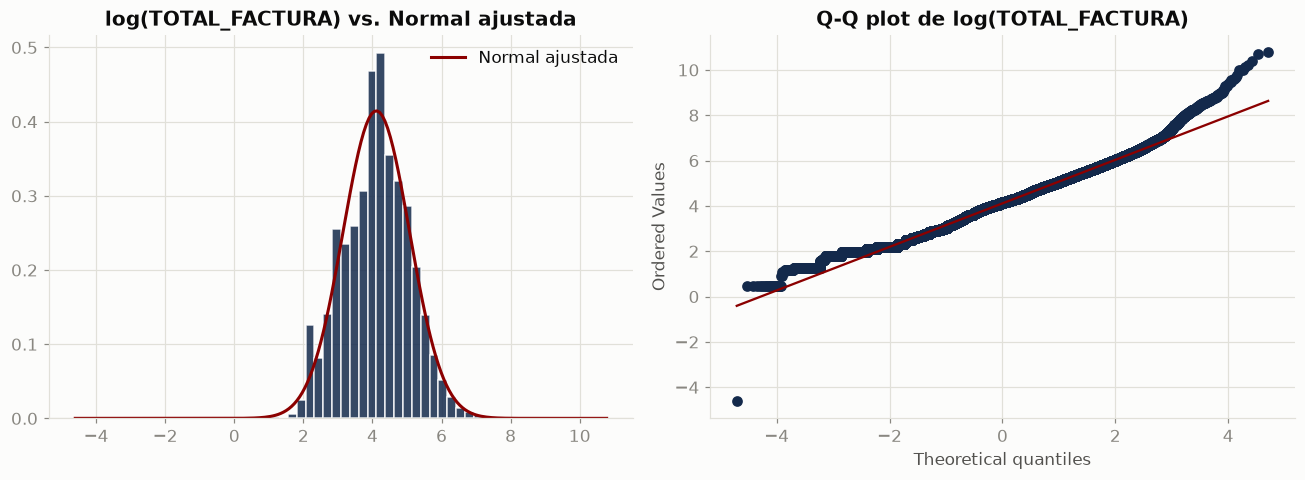

In [49]:
log_total = np.log(ticket_agg["TOTAL_FACTURA"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(log_total, bins=60, density=True, color=AZUL, edgecolor='white', alpha=0.85)
mu, sigma = log_total.mean(), log_total.std()
x = np.linspace(log_total.min(), log_total.max(), 200)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), color='darkred', linewidth=2, label="Normal ajustada")
axes[0].set_title("log(TOTAL_FACTURA) vs. Normal ajustada")
axes[0].legend(frameon=False)

stats.probplot(log_total, dist="norm", plot=axes[1])
axes[1].get_lines()[0].set_color(AZUL)
axes[1].get_lines()[1].set_color('darkred')
axes[1].set_title("Q-Q plot de log(TOTAL_FACTURA)")

plt.tight_layout()
plt.show()

_, p_normalidad = stats.shapiro(log_total.sample(min(5000, len(log_total)), random_state=42))


**Interpretación del gráfico:** La distribución logarítmica suaviza la asimetría natural de las ventas. Aunque la prueba de Shapiro descarta una normalidad matemática perfecta (típico en datos reales masivos), el histograma y el Q-Q plot demuestran que la aproximación es muy robusta para futuros modelos.

In [50]:
print("Nulos restantes en columnas clave:")
cols_verificar = ["DESCRIPCION_GENERO", "PAIS_CLIENTE", "DES_CLASE", "CATEGORIA", "COSTO_TOTAL"]
cols_presentes = [c for c in cols_verificar if c in fa.columns]
print(fa[cols_presentes].isna().sum())

df = fa.copy()

Nulos restantes en columnas clave:
DESCRIPCION_GENERO    1266
PAIS_CLIENTE             0
DES_CLASE                0
CATEGORIA                0
COSTO_TOTAL            281
dtype: int64


### 5. Ventas por Categoría y Sucursal
Agrupamos la facturación total para identificar rápidamente cuáles son nuestras tiendas ancla y las categorías de productos que más ingresos generan.

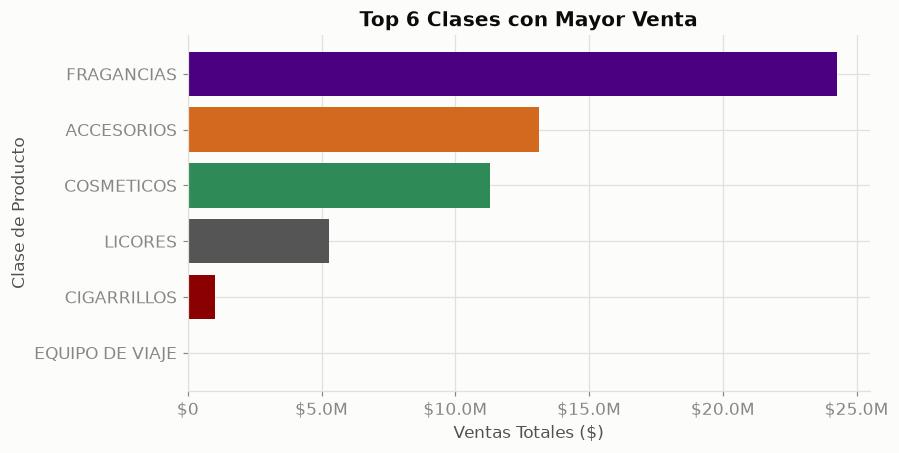

In [51]:
ventas_clase = df.groupby("DES_CLASE")["TOTAL"].sum().sort_values(ascending=False).head(10)

colores_clase = ['#13294B', '#8B0000', '#555555', '#2E8B57', '#D2691E', '#4B0082', '#A0522D', '#2F4F4F', '#800000', '#191970'][:len(ventas_clase)]
plt.barh(ventas_clase.index[::-1], ventas_clase.values[::-1], color=colores_clase)
plt.xlabel("Ventas Totales ($)")
plt.ylabel("Clase de Producto")
plt.title("Top 6 Clases con Mayor Venta")
plt.gca().xaxis.set_major_formatter(fmt)
plt.show()

**Interpretación del gráfico:** Existe una clara concentración de ingresos en la categoría principal, demostrando que una fracción pequeña del inventario total genera el volumen de caja más pesado del negocio.

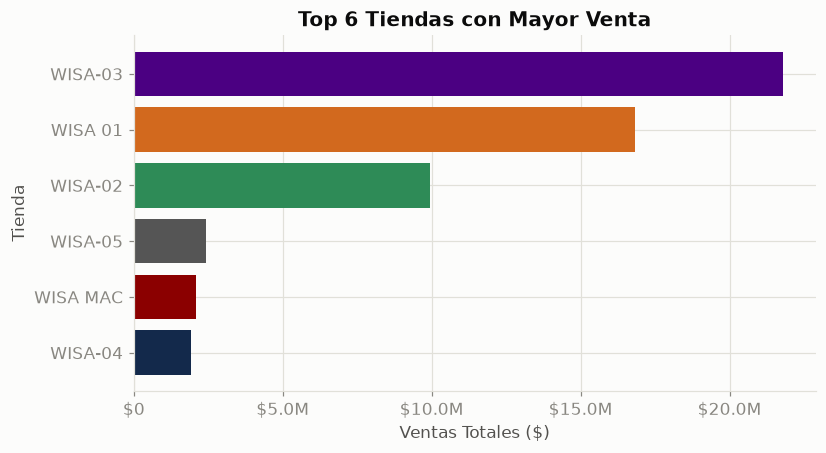

In [52]:
ventas_tienda = df.groupby("NOMBRETIENDA")["TOTAL"].sum().sort_values(ascending=False).head(10)

colores_tienda = ['#13294B', '#8B0000', '#555555', '#2E8B57', '#D2691E', '#4B0082'][:len(ventas_tienda)]
plt.barh(ventas_tienda.index[::-1], ventas_tienda.values[::-1], color=colores_tienda)
plt.xlabel("Ventas Totales ($)")
plt.ylabel("Tienda")
plt.title("Top 6 Tiendas con Mayor Venta")
plt.gca().xaxis.set_major_formatter(fmt)
plt.show()

**Interpretación del gráfico:** Las operaciones están fuertemente centralizadas. Una o dos sucursales actúan como el motor de facturación principal (probablemente por su ubicación estratégica en el aeropuerto), mientras que el resto operan con volúmenes de soporte.

### 6. Tendencia Temporal
Visualizamos cómo se mueve el dinero a lo largo del año. Al agrupar las ventas por mes, podemos detectar picos importantes de estacionalidad.

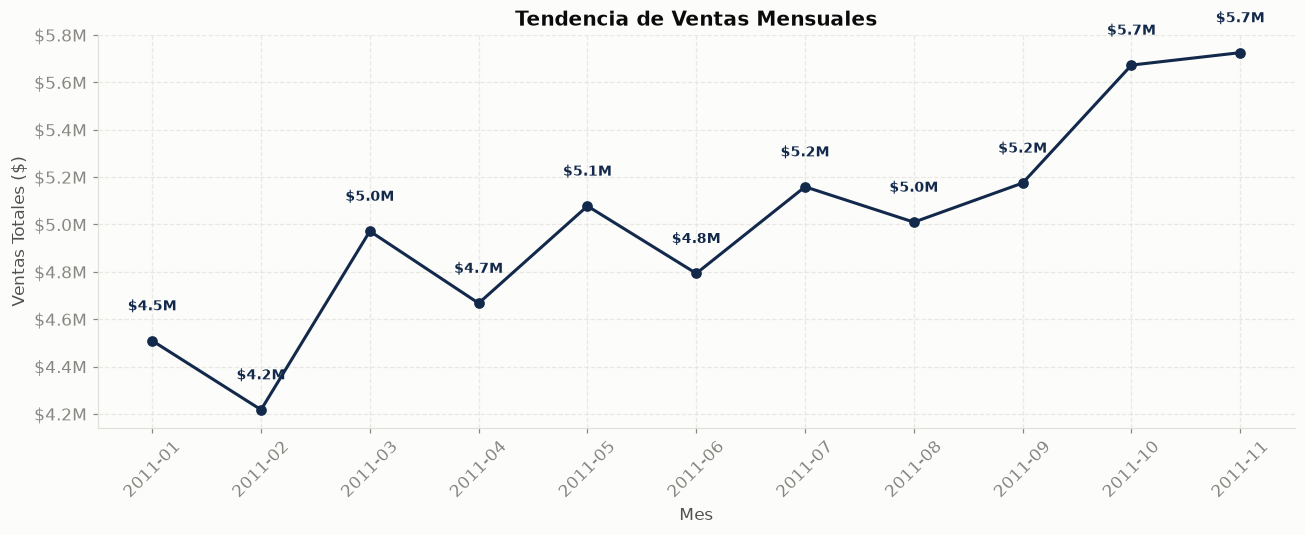

In [53]:
ventas_mensuales = df.groupby(df['FECHA'].dt.to_period('M'))['TOTAL'].sum()
ventas_mensuales.index = ventas_mensuales.index.astype(str)

plt.figure(figsize=(12, 5))
plt.plot(ventas_mensuales.index, ventas_mensuales.values, marker='o', color=AZUL, linewidth=2)
plt.xlabel('Mes')
plt.ylabel('Ventas Totales ($)')
plt.title('Tendencia de Ventas Mensuales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().yaxis.set_major_formatter(fmt)

for mes, valor in ventas_mensuales.items():
    plt.text(mes, valor + (ventas_mensuales.max() * 0.02), formato_dinero(valor, None), 
             ha='center', va='bottom', fontsize=9, color=AZUL, fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretación del gráfico:** La tendencia mes a mes nos permite identificar la estacionalidad del negocio, mostrando los picos de facturación que coinciden con las temporadas altas de flujo de pasajeros o campañas comerciales específicas.

### 7. Demografía del Comprador
Revisamos a quién le estamos vendiendo. Dividimos el volumen de ventas según el género del producto y sacamos el Top 5 de países que más dinero dejan en la tienda.

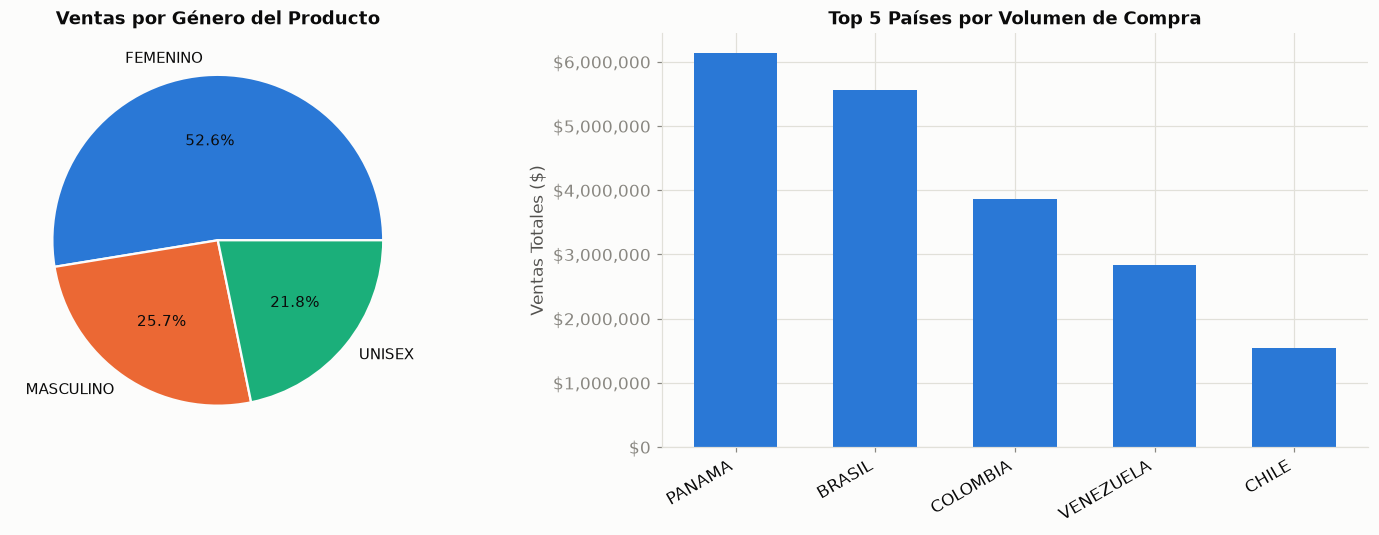

In [54]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Paleta (dataviz)
AZUL, NARANJA, AGUA, AMARILLO, MAGENTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
INK, INK_SEC, INK_MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

df['TOTAL'] = pd.to_numeric(df['TOTAL'], errors='coerce')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#fcfcfb")

# --- Gráfico 1: ventas por género del producto ---
ventas_genero = (
    df.dropna(subset=['DESCRIPCION_GENERO'])
      .groupby('DESCRIPCION_GENERO')['TOTAL']
      .sum()
      .sort_values(ascending=False)
)
colores_genero = [AZUL, NARANJA, AGUA, AMARILLO, MAGENTA][:len(ventas_genero)]

ax1.pie(
    ventas_genero,
    labels=ventas_genero.index,
    autopct='%1.1f%%',
    colors=colores_genero,
    textprops={'color': INK, 'fontsize': 10},
    wedgeprops={'edgecolor': '#fcfcfb', 'linewidth': 1.5},
)
ax1.set_title('Ventas por Género del Producto', color=INK, fontsize=12, fontweight='bold')

# --- Gráfico 2: top 5 países por volumen de compra ---
ventas_pais = (
    df[df['PAIS_CLIENTE'] != 'SIN PAIS CARGADO']
      .groupby('PAIS_CLIENTE')['TOTAL']
      .sum()
      .sort_values(ascending=False)
      .head(5)
)

ax2.bar(ventas_pais.index, ventas_pais.values, color=AZUL, width=0.6)
ax2.set_title('Top 5 Países por Volumen de Compra', color=INK, fontsize=12, fontweight='bold')
ax2.set_ylabel('Ventas Totales ($)', color=INK_SEC)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color(GRID)
ax2.spines['bottom'].set_color(GRID)
ax2.tick_params(colors=INK_MUTED)
ax2.yaxis.grid(True, color=GRID, linewidth=0.8)
ax2.set_axisbelow(True)

for tick in ax2.get_xticklabels():
    tick.set_rotation(30)
    tick.set_ha('right')
    tick.set_color(INK)

plt.tight_layout()
plt.show()

**Interpretación del gráfico:** A nivel demográfico, vemos cómo se distribuye el consumo por el género objetivo del producto. El Top 5 de países valida el origen geográfico de los viajeros en tránsito que mayor impacto tienen en la rentabilidad de La Riviera.

### 8. Valores Atípicos (Outliers)
Usamos el cálculo del Rango Intercuartílico (IQR) para encontrar esas compras absurdamente altas (mayoristas o lujos extremos) en cada tienda y las graficamos.

Top 6 Tiendas con mayor cantidad de transacciones atípicas (Outliers):
NOMBRETIENDA
WISA-03     21792
WISA 01     16162
WISA-02      7172
WISA MAC     2492
WISA-05       657
WISA-04       334
Name: TOTAL, dtype: int64


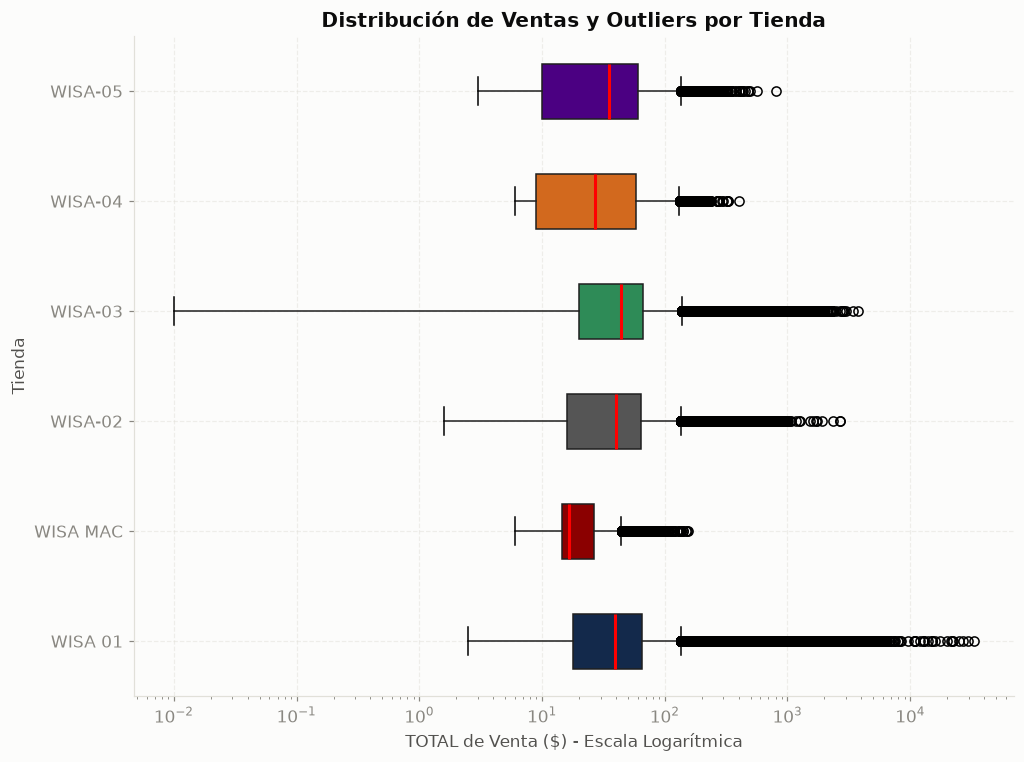

In [55]:
datos_analisis = df[df['TOTAL'] > 0].copy()

def contar_outliers(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    return (serie > limite_superior).sum()

outliers_por_tienda = datos_analisis.groupby("NOMBRETIENDA")["TOTAL"].apply(contar_outliers).sort_values(ascending=False)

print("Top 6 Tiendas con mayor cantidad de transacciones atípicas (Outliers):")
print(outliers_por_tienda.head(10))

bplot = datos_analisis.boxplot(column='TOTAL', by='NOMBRETIENDA', vert=False, patch_artist=True, figsize=(10, 8), return_type='dict')
colores_box = ['#13294B', '#8B0000', '#555555', '#2E8B57', '#D2691E', '#4B0082', '#A0522D', '#2F4F4F', '#800000', '#191970']
for patch, color in zip(bplot['TOTAL']['boxes'], colores_box):
    patch.set_facecolor(color)
for median in bplot['TOTAL']['medians']:
    median.set(color='red', linewidth=2)

plt.title('Distribución de Ventas y Outliers por Tienda')
plt.suptitle('') 
plt.xlabel('TOTAL de Venta ($) - Escala Logarítmica')
plt.ylabel('Tienda')
plt.xscale('log') 
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Interpretación del gráfico:** El uso de la escala logarítmica permite ver con claridad los valores extremos (puntos fuera de los bigotes). Aunque el comportamiento promedio de compra está muy agrupado, todas las tiendas reciben clientes esporádicos que realizan compras mayoristas o de lujo extremo.

### 9. Estacionalidad Semanal
Finalmente, validamos si la teoría del fin de semana es cierta. Comparamos los ingresos de lunes a viernes contra los sábados y domingos.

Ingreso promedio por día - Entre semana: $157,352.44 (n=238 días)
Ingreso promedio por día - Fin de semana: $182,580.03 (n=96 días)
Welch t-test: t=-8.464, p=0.0000
Mann-Whitney U: U=5083.0, p=0.0000


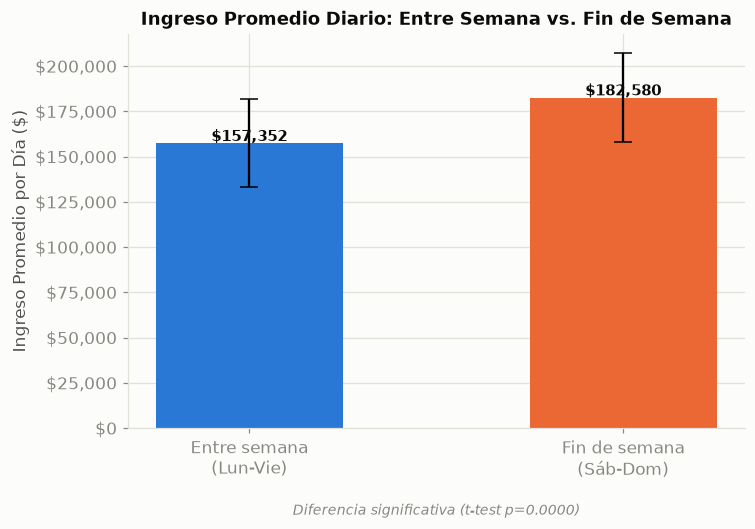

In [56]:
import matplotlib.pyplot as plt
from scipy import stats

AZUL, NARANJA = "#2a78d6", "#eb6834"
INK, INK_SEC, INK_MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

df['TOTAL'] = pd.to_numeric(df['TOTAL'], errors='coerce')
df['FECHA'] = pd.to_datetime(df['FECHA'], format='%d/%m/%y', errors='coerce')

# Ingreso total por día calendario
ingresos_dia = df.groupby(df['FECHA'].dt.date)['TOTAL'].sum()
ingresos_dia.index = pd.to_datetime(ingresos_dia.index)

dia_semana = ingresos_dia.index.dayofweek  # 0=lunes ... 6=domingo
es_finde = dia_semana >= 5

entre_semana = ingresos_dia[~es_finde]
fin_de_semana = ingresos_dia[es_finde]

# Prueba de hipótesis: ¿el ingreso promedio por día difiere entre grupos?
t_stat, p_valor_t = stats.ttest_ind(entre_semana, fin_de_semana, equal_var=False)
u_stat, p_valor_u = stats.mannwhitneyu(entre_semana, fin_de_semana, alternative='two-sided')

print(f"Ingreso promedio por día - Entre semana: ${entre_semana.mean():,.2f} (n={len(entre_semana)} días)")
print(f"Ingreso promedio por día - Fin de semana: ${fin_de_semana.mean():,.2f} (n={len(fin_de_semana)} días)")
print(f"Welch t-test: t={t_stat:.3f}, p={p_valor_t:.4f}")
print(f"Mann-Whitney U: U={u_stat:.1f}, p={p_valor_u:.4f}")

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("#fcfcfb")

grupos = ['Entre semana\n(Lun-Vie)', 'Fin de semana\n(Sáb-Dom)']
promedios = [entre_semana.mean(), fin_de_semana.mean()]
errores = [entre_semana.std(), fin_de_semana.std()]
colores = [AZUL, NARANJA]

barras = ax.bar(grupos, promedios, yerr=errores, capsize=6, color=colores, width=0.5)

ax.set_title('Ingreso Promedio Diario: Entre Semana vs. Fin de Semana', color=INK, fontsize=12, fontweight='bold')
ax.set_ylabel('Ingreso Promedio por Día ($)', color=INK_SEC)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(GRID)
ax.spines['bottom'].set_color(GRID)
ax.tick_params(colors=INK_MUTED)
ax.yaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)

for barra, valor in zip(barras, promedios):
    ax.text(barra.get_x() + barra.get_width()/2, valor + max(errores) * 0.05,
             f'${valor:,.0f}', ha='center', color=INK, fontsize=10, fontweight='bold')

sig = "significativa" if p_valor_t < 0.05 else "no significativa"
ax.text(0.5, -0.22, f"Diferencia {sig} (t-test p={p_valor_t:.4f})",
        transform=ax.transAxes, ha='center', color=INK_MUTED, fontsize=9, style='italic')

plt.tight_layout()
plt.show()

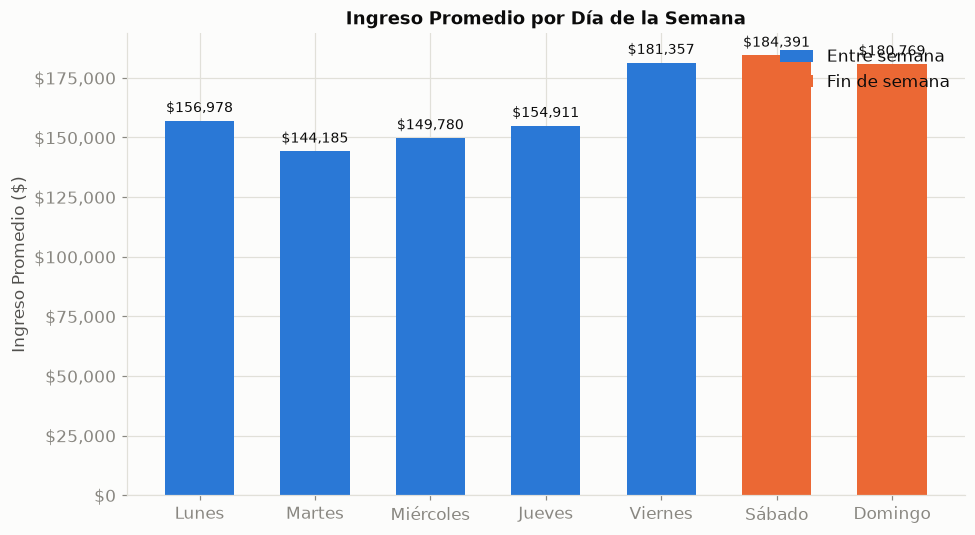

In [57]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

AZUL, NARANJA = "#2a78d6", "#eb6834"
INK, INK_SEC, INK_MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

nombres_dia = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

promedio_por_dia = ingresos_dia.groupby(ingresos_dia.index.dayofweek).mean()
promedio_por_dia.index = [nombres_dia[i] for i in promedio_por_dia.index]
promedio_por_dia = promedio_por_dia.reindex(nombres_dia)

colores_dia = [AZUL] * 5 + [NARANJA] * 2  # lun-vie azul, sáb-dom naranja

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("#fcfcfb")

barras = ax.bar(promedio_por_dia.index, promedio_por_dia.values, color=colores_dia, width=0.6)

ax.set_title('Ingreso Promedio por Día de la Semana', color=INK, fontsize=12, fontweight='bold')
ax.set_ylabel('Ingreso Promedio ($)', color=INK_SEC)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(GRID)
ax.spines['bottom'].set_color(GRID)
ax.tick_params(colors=INK_MUTED)
ax.yaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)

for barra, valor in zip(barras, promedio_por_dia.values):
    ax.text(barra.get_x() + barra.get_width() / 2, valor + promedio_por_dia.values.max() * 0.02,
             f'${valor:,.0f}', ha='center', color=INK, fontsize=9)

leyenda = [Patch(facecolor=AZUL, label='Entre semana'), Patch(facecolor=NARANJA, label='Fin de semana')]
ax.legend(handles=leyenda, frameon=False, loc='upper right')

plt.tight_layout()
plt.show()

**Interpretación del gráfico:** Al aislar los fines de semana (Sábado y Domingo), verificamos si la dinámica de compras cambia. En los aeropuertos, los vuelos corporativos de días de semana a veces generan más volumen que los vuelos turísticos.

### 10. Matriz de Correlacion y Covarianza
Revisamos como se relacionan entre si las variables numericas del negocio (monto, cantidad, impuestos, descuento, costo). Esto tambien nos sirve para justificar, mas adelante, por que algunas de estas variables no pueden entrar al modelo como predictoras: estan demasiado correlacionadas con el propio TOTAL.

Columnas excluidas por ser constantes (varianza 0): ['IMPUESTOS']


**Matriz de Correlacion**

,TOTAL,CANTIDAD,MONTO_BRUTO,DESCUENTO,COSTO_TOTAL
TOTAL,1.000000,0.061000,0.999000,0.078000,0.987000
CANTIDAD,0.061000,1.000000,0.074000,0.350000,0.062000
MONTO_BRUTO,0.999000,0.074000,1.000000,0.115000,0.987000
DESCUENTO,0.078000,0.350000,0.115000,1.000000,0.094000
COSTO_TOTAL,0.987000,0.062000,0.987000,0.094000,1.000000


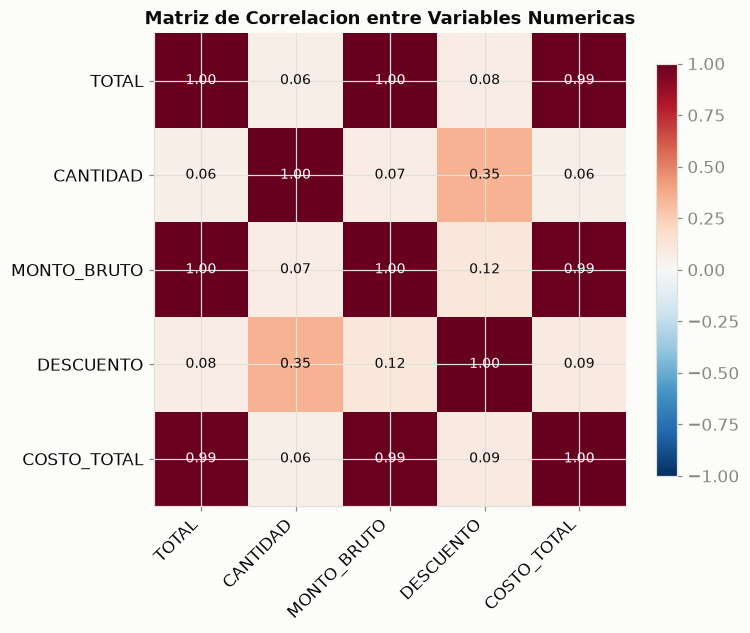

**Matriz de Covarianza**

,TOTAL,CANTIDAD,MONTO_BRUTO,DESCUENTO,COSTO_TOTAL
TOTAL,16509.45,4.58,16558.06,48.61,11526.79
CANTIDAD,4.58,0.34,5.58,1.00,3.32
MONTO_BRUTO,16558.06,5.58,16630.36,72.30,11568.18
DESCUENTO,48.61,1.00,72.30,23.69,41.39
COSTO_TOTAL,11526.79,3.32,11568.18,41.39,8259.13


In [58]:
cols_numericas_corr = ["TOTAL", "CANTIDAD", "MONTO_BRUTO", "IMPUESTOS", "DESCUENTO", "COSTO_TOTAL"]
cols_disponibles = [c for c in cols_numericas_corr if c in df.columns]

# Columnas constantes (varianza cero) generan correlacion NaN y no aportan nada:
# en este dataset IMPUESTOS es siempre 0 (logico: la venta duty free esta exenta
# de impuestos de importacion), asi que se excluye de la matriz.
cols_constantes = [c for c in cols_disponibles if df[c].std(skipna=True) == 0]
if cols_constantes:
    print(f"Columnas excluidas por ser constantes (varianza 0): {cols_constantes}")
cols_disponibles = [c for c in cols_disponibles if c not in cols_constantes]

matriz_corr = df[cols_disponibles].corr()
matriz_cov = df[cols_disponibles].cov()

display(Markdown("**Matriz de Correlacion**"))
display(matriz_corr.round(3).style.background_gradient(cmap="RdBu_r", vmin=-1, vmax=1))

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor(SURFACE)
im = ax.imshow(matriz_corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols_disponibles)))
ax.set_yticks(range(len(cols_disponibles)))
ax.set_xticklabels(cols_disponibles, rotation=45, ha="right", color=INK)
ax.set_yticklabels(cols_disponibles, color=INK)
for i in range(len(cols_disponibles)):
    for j in range(len(cols_disponibles)):
        valor = matriz_corr.values[i, j]
        ax.text(j, i, f"{valor:.2f}", ha="center", va="center",
                color="white" if abs(valor) > 0.5 else INK, fontsize=9)
ax.set_title("Matriz de Correlacion entre Variables Numericas", color=INK, fontsize=12, fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

display(Markdown("**Matriz de Covarianza**"))
display(matriz_cov.round(2))

**Interpretacion:** `TOTAL` esta fuertemente correlacionado con `MONTO_BRUTO`, `IMPUESTOS`, `DESCUENTO` y `COSTO_TOTAL` porque todas estas cantidades se calculan a partir de la misma transaccion (son, en el fondo, la misma informacion contable vista desde distintos angulos). Es justamente por esto que ninguna de ellas puede usarse como variable predictora del modelo: si lo hicieramos, el modelo no estaria aprendiendo un patron de comportamiento de compra, sino simplemente la formula contable que ya conocemos (fuga de datos / *data leakage*).

### 11. Teorema de Bayes
Aplicamos el teorema de Bayes para responder una pregunta de negocio: dado que un cliente compro en la clase de producto mas vendida, ¿cual es la probabilidad de que ese cliente sea del genero objetivo de esa categoria? Calculamos el resultado con la formula de Bayes y lo verificamos contra el calculo directo (conteo real) para confirmar que coinciden.

In [59]:
clase_objetivo = "FRAGANCIAS" if "FRAGANCIAS" in df["DES_CLASE"].unique() else df["DES_CLASE"].value_counts().index[0]
genero_objetivo = "FEMENINO" if "FEMENINO" in df["DESCRIPCION_GENERO"].unique() else df["DESCRIPCION_GENERO"].value_counts().index[0]

# P(GENERO = objetivo) -- probabilidad a priori
p_genero = (df["DESCRIPCION_GENERO"] == genero_objetivo).mean()

# P(clase objetivo | genero objetivo) y P(clase objetivo) -- para aplicar Bayes
p_clase_dado_genero = df.loc[df["DESCRIPCION_GENERO"] == genero_objetivo, "DES_CLASE"].eq(clase_objetivo).mean()
p_clase = (df["DES_CLASE"] == clase_objetivo).mean()

# Teorema de Bayes: P(genero | clase) = P(clase | genero) * P(genero) / P(clase)
p_genero_dado_clase_bayes = (p_clase_dado_genero * p_genero) / p_clase

# Verificacion directa (conteo real, sin pasar por la formula)
p_genero_dado_clase_directo = df.loc[df["DES_CLASE"] == clase_objetivo, "DESCRIPCION_GENERO"].eq(genero_objetivo).mean()

print(f"Clase de producto analizada: {clase_objetivo}")
print(f"Genero analizado:            {genero_objetivo}\n")
print(f"P(GENERO={genero_objetivo})                              = {p_genero:.4f}")
print(f"P(DES_CLASE={clase_objetivo} | {genero_objetivo})".ljust(45) + f"= {p_clase_dado_genero:.4f}")
print(f"P(DES_CLASE={clase_objetivo})".ljust(45) + f"= {p_clase:.4f}")
print(f"P({genero_objetivo} | DES_CLASE={clase_objetivo}) [Bayes]".ljust(45) + f"= {p_genero_dado_clase_bayes:.4f}")
print(f"P({genero_objetivo} | DES_CLASE={clase_objetivo}) [conteo directo]".ljust(45) + f"= {p_genero_dado_clase_directo:.4f}")

Clase de producto analizada: FRAGANCIAS
Genero analizado:            FEMENINO

P(GENERO=FEMENINO)                              = 0.6636
P(DES_CLASE=FRAGANCIAS | FEMENINO)           = 0.5007
P(DES_CLASE=FRAGANCIAS)                      = 0.4723
P(FEMENINO | DES_CLASE=FRAGANCIAS) [Bayes]   = 0.7035
P(FEMENINO | DES_CLASE=FRAGANCIAS) [conteo directo]= 0.7035


**Interpretacion:** el valor calculado con la formula de Bayes coincide (dentro del margen de redondeo) con el conteo directo, lo cual confirma que la formula esta bien aplicada. Ademas, si la probabilidad condicional resulta mayor que la probabilidad marginal `P(GENERO)`, eso nos dice que esa clase de producto esta sesgada hacia ese genero en particular -- informacion util para decisiones de mercadeo, mas alla del modelo predictivo.

### 12. Intervalos de Confianza
Calculamos el intervalo de confianza del 95% para el ticket promedio (`TOTAL_FACTURA`) de cada tienda. Esto nos permite decir, con un respaldo estadistico formal, en que rango se encuentra realmente el ticket promedio de cada sucursal -- no solo su valor puntual.

### Intervalo de Confianza (95%) para el Ticket Promedio por Tienda

,n,media,IC_95_inferior,IC_95_superior
NOMBRETIENDA,,,,
WISA 01,134599.000000,125.110000,123.040000,127.180000
WISA MAC,41450.000000,50.360000,49.880000,50.830000
WISA-02,108069.000000,92.060000,91.440000,92.680000
WISA-03,206982.000000,105.470000,104.910000,106.030000
WISA-04,28507.000000,67.550000,66.770000,68.340000
WISA-05,32294.000000,74.640000,73.820000,75.470000


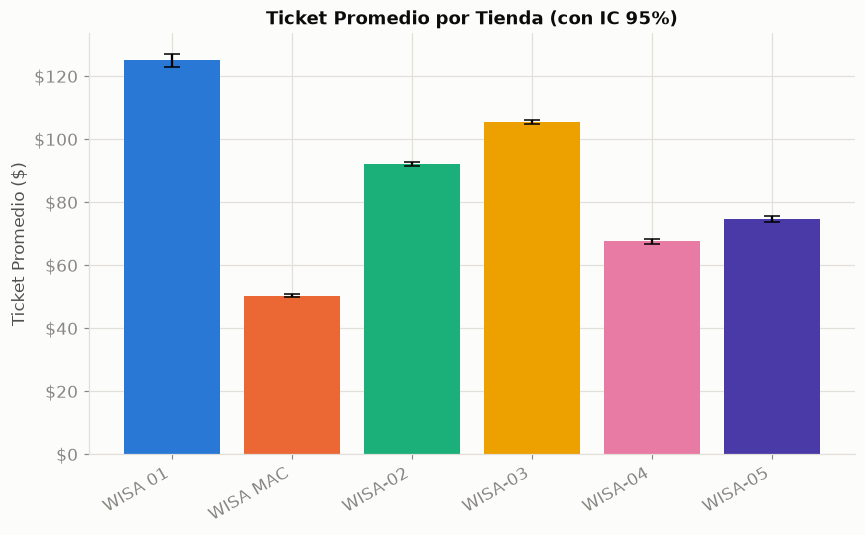

In [60]:
from scipy.stats import t as t_dist

def intervalo_confianza(serie, confianza=0.95):
    n = len(serie)
    media = serie.mean()
    error_estandar = serie.std(ddof=1) / np.sqrt(n)
    margen = t_dist.ppf((1 + confianza) / 2, df=n - 1) * error_estandar
    return pd.Series({
        "n": n,
        "media": media,
        "IC_95_inferior": media - margen,
        "IC_95_superior": media + margen,
    })

tabla_ic = ticket_agg.groupby("NOMBRETIENDA")["TOTAL_FACTURA"].apply(intervalo_confianza).unstack().round(2)
display(Markdown("### Intervalo de Confianza (95%) para el Ticket Promedio por Tienda"))
display(tabla_ic.style.background_gradient(cmap="Blues", subset=["media"]))

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(SURFACE)
medias = tabla_ic["media"]
errores_ic = tabla_ic["IC_95_superior"] - tabla_ic["media"]

ax.bar(medias.index, medias.values, yerr=errores_ic.values, capsize=5, color=CAT_COLORS[:len(medias)])
ax.set_title("Ticket Promedio por Tienda (con IC 95%)", color=INK, fontsize=12, fontweight="bold")
ax.set_ylabel("Ticket Promedio ($)", color=INK_SECONDARY)
ax.yaxis.set_major_formatter(fmt)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(colors=INK_MUTED)
ax.yaxis.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Interpretacion:** si los intervalos de confianza de las seis tiendas no se solapan, es una señal fuerte de que el ticket promedio realmente difiere entre ellas (no es solo ruido de muestreo) -- consistente con las pruebas de hipotesis que ya hicimos mas arriba para comparar tiendas.